# Отчет по РК1: Масштабирование и кодирование категориальных признаков

**Датасет:** Admission_Predict.csv  
**Объем:** 400 образцов, 9 признаков  
**Задача:** Масштабирование числовых признаков и преобразование категориальных признаков двумя способами (Label Encoding, One-Hot Encoding)

In [14]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

# Настройка стиля для графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка датасета
try:
    df = pd.read_csv('Admission_Predict.csv')
    print("✓ Данные успешно загружены!")
    print(f"Форма датасета: {df.shape}")
except FileNotFoundError:
    print("Ошибка: Файл 'Admission_Predict.csv' не найден в текущей директории.")

# Вывод первых 5 строк датасета
print("\nПервые 5 строк датасета:")
print(df.head())

✓ Данные успешно загружены!
Форма датасета: (400, 9)

Первые 5 строк датасета:
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


## 1. Масштабирование данных

В качестве числового признака для масштабирования выберем признак `GRE Score` (оценка GRE).
Мы применим нормализацию (StandardScaler и MinMaxScaler), чтобы привести значения к стандартизированному виду с нулевым средним и единичной дисперсией, а также к диапазону [0, 1].

In [15]:
# Способ 1: StandardScaler
scaler_standard = StandardScaler()
df['GRE_Score_StandardScaler'] = scaler_standard.fit_transform(df[['GRE Score']])

# Способ 2: MinMaxScaler
scaler_minmax = MinMaxScaler()
df['GRE_Score_MinMaxScaler'] = scaler_minmax.fit_transform(df[['GRE Score']])

print("Сравнение исходного и масштабированного признаков:")
print("\nИсходные данные (GRE Score):")
print(f"  Min: {df['GRE Score'].min():.2f}")
print(f"  Max: {df['GRE Score'].max():.2f}")
print(f"  Mean: {df['GRE Score'].mean():.2f}")
print(f"  Std: {df['GRE Score'].std():.2f}")

print("\nПосле StandardScaler:")
print(f"  Min: {df['GRE_Score_StandardScaler'].min():.4f}")
print(f"  Max: {df['GRE_Score_StandardScaler'].max():.4f}")
print(f"  Mean: {df['GRE_Score_StandardScaler'].mean():.4f}")
print(f"  Std: {df['GRE_Score_StandardScaler'].std():.4f}")

print("\nПосле MinMaxScaler:")
print(f"  Min: {df['GRE_Score_MinMaxScaler'].min():.4f}")
print(f"  Max: {df['GRE_Score_MinMaxScaler'].max():.4f}")
print(f"  Mean: {df['GRE_Score_MinMaxScaler'].mean():.4f}")

# Выведем примеры
print("\nПримеры преобразованных значений:")
print(df[['GRE Score', 'GRE_Score_StandardScaler', 'GRE_Score_MinMaxScaler']].head(10))

Сравнение исходного и масштабированного признаков:

Исходные данные (GRE Score):
  Min: 290.00
  Max: 340.00
  Mean: 316.81
  Std: 11.47

После StandardScaler:
  Min: -2.3394
  Max: 2.0239
  Mean: -0.0000
  Std: 1.0013

После MinMaxScaler:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.5362

Примеры преобразованных значений:
   GRE Score  GRE_Score_StandardScaler  GRE_Score_MinMaxScaler
0        337                  1.762107                    0.94
1        324                  0.627656                    0.68
2        316                 -0.070467                    0.52
3        322                  0.453126                    0.64
4        314                 -0.244998                    0.48
5        330                  1.151249                    0.80
6        321                  0.365860                    0.62
7        308                 -0.768590                    0.36
8        302                 -1.292182                    0.24
9        323                  0.540391              

## 2. Преобразование категориальных признаков в количественные

Для этого задания выберем категориальный признак `Research` (наличие научных публикаций), который имеет бинарные значения (0 или 1).
Выполним кодирование двумя способами:
1. **Label Encoding** — замена уникальных значений на целые числа (0 → 0, 1 → 1).
2. **One-Hot Encoding** — создание новых бинарных признаков (dummy-переменных) для каждого значения.

In [16]:
# Создаем копию для кодирования
df_encoded = df.copy()

# Способ 1: Label Encoding
le = LabelEncoder()
df_encoded['Research_LabelEncoded'] = le.fit_transform(df_encoded['Research'])

print("Label Encoding результат:")
print(f"Оригинальные значения: {sorted(df['Research'].unique())}")
print(f"Label Encoded значения: {sorted(df_encoded['Research_LabelEncoded'].unique())}")
print(f"Маппинг: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Способ 2: One-Hot Encoding
# Используем встроенную функцию pandas: get_dummies
df_encoded = pd.get_dummies(df_encoded, columns=['Research'], prefix='Research_OHE', dtype=int)

# Выведем результат
columns_to_show = ['Research_LabelEncoded'] + [col for col in df_encoded.columns if 'Research_OHE' in col]
print("\n\nОбщий вид преобразованных данных:")
print(df_encoded[columns_to_show].head(15))

Label Encoding результат:
Оригинальные значения: [np.int64(0), np.int64(1)]
Label Encoded значения: [np.int64(0), np.int64(1)]
Маппинг: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


Общий вид преобразованных данных:
    Research_LabelEncoded  Research_OHE_0  Research_OHE_1
0                       1               0               1
1                       1               0               1
2                       1               0               1
3                       1               0               1
4                       0               1               0
5                       1               0               1
6                       1               0               1
7                       0               1               0
8                       0               1               0
9                       0               1               0
10                      1               0               1
11                      1               0               1
12                   

## 3. Обоснование выбора методов

### Масштабирование (StandardScaler и MinMaxScaler)
Я использовал два метода масштабирования для признака `GRE Score`:

1. **StandardScaler (Z-нормализация)**: преобразует данные так, чтобы они имели нулевое среднее значение (mean = 0) и единичное стандартное отклонение (std = 1). Этот метод сохраняет форму исходного распределения и является наиболее универсальным. **Рекомендуется** для алгоритмов, чувствительных к масштабу данных (линейная/логистическая регрессия, SVM, нейронные сети, KNN).

2. **MinMaxScaler**: приводит все значения к диапазону [0, 1], сохраняя соотношение между ними. **Рекомендуется** для алгоритмов, требующих ограниченный диапазон (деревья решений иногда, нейронные сети с сигмоид-функциями).

### Label Encoding
Этот метод просто заменяет каждое уникальное значение на целое число. Для признака `Research` (бинарный: 0 и 1) он создает простое отображение. **Преимущества**: экономия памяти, простота, быстрота. **Недостатки**: создает ложный математический порядок между значениями, что может отрицательно повлиять на линейные модели. **Применение**: деревья решений (XGBoost, LightGBM), которые нечувствительны к упорядочению категорий.

### One-Hot Encoding
Создает отдельный бинарный столбец для каждой категории. Для бинарного признака это создает два столбца: `Research_OHE_0` и `Research_OHE_1`. **Преимущества**: не вводит ложный порядок, правильно обрабатывает номинальные данные, хорошо работает с линейными моделями. **Недостатки**: увеличивает размерность (важно для признаков с множеством категорий), может привести к мультиколлинеарности. **Применение**: линейные модели (регрессия, логистическая регрессия), нейронные сети.

**Выводы:** Для данного датасета рекомендуется использовать **StandardScaler для масштабирования GRE Score** (универсален и эффективен) и **One-Hot Encoding для Research** (для линейных моделей) или **Label Encoding** (для деревьев решений).

## 4. Визуализация масштабирования

Построим гистограммы, чтобы увидеть, как меняется распределение признака `GRE Score` после масштабирования.

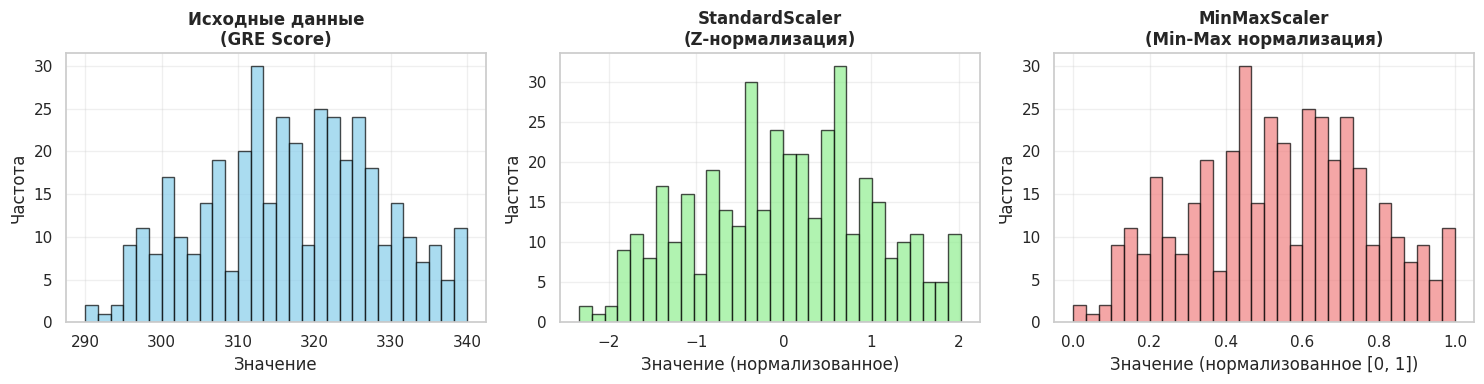

In [17]:
# Создаем три подграфика для сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График 1: Исходные данные
axes[0].hist(df['GRE Score'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Исходные данные\n(GRE Score)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')
axes[0].grid(alpha=0.3)

# График 2: После StandardScaler
axes[1].hist(df['GRE_Score_StandardScaler'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('StandardScaler\n(Z-нормализация)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Значение (нормализованное)')
axes[1].set_ylabel('Частота')
axes[1].grid(alpha=0.3)

# График 3: После MinMaxScaler
axes[2].hist(df['GRE_Score_MinMaxScaler'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[2].set_title('MinMaxScaler\n(Min-Max нормализация)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Значение (нормализованное [0, 1])')
axes[2].set_ylabel('Частота')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Визуализация связи между признаками

Построим скрипичную диаграмму (Violin Plot) для анализа распределения шанса поступления в зависимости от наличия научных публикаций (Research).

/tmp/ipykernel_11530/4101990734.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


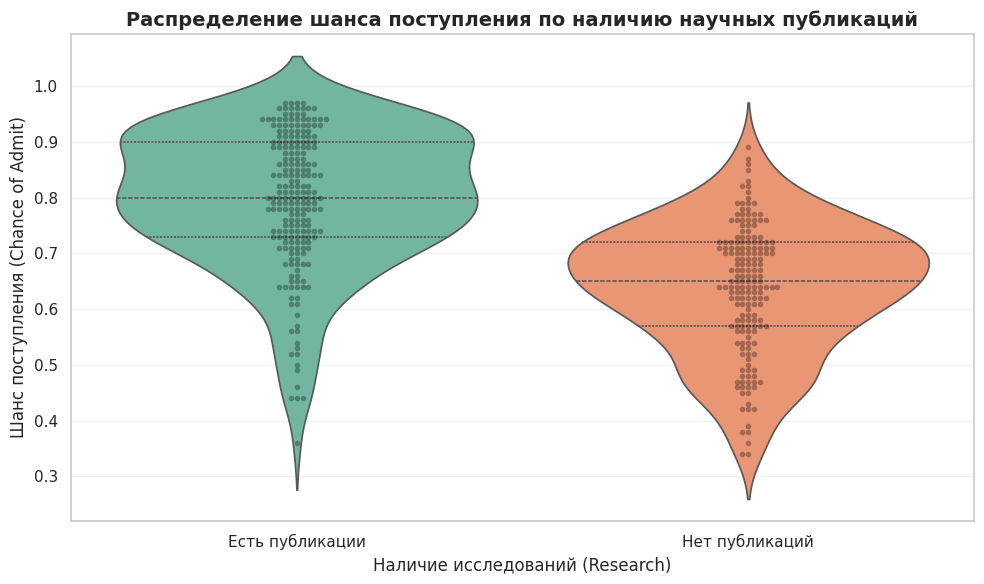

In [18]:
# Создаем полотно нужного размера
plt.figure(figsize=(10, 6))

# Преобразуем Research в строки для более читаемых подписей
research_labels = df['Research'].map({0: 'Нет публикаций', 1: 'Есть публикации'})

# Строим Violin plot
sns.violinplot(
    x=research_labels,
    y='Chance of Admit ',
    data=df,
    palette='Set2',
    inner='quartile'  # Отображение квартилей внутри скрипок
)

# Добавляем точки данных для лучшей визуализации
sns.swarmplot(
    x=research_labels,
    y='Chance of Admit ',
    data=df,
    color='black',
    alpha=0.3,
    size=4
)

# Добавляем заголовки и подписи осей
plt.title('Распределение шанса поступления по наличию научных публикаций', fontsize=14, fontweight='bold')
plt.xlabel('Наличие исследований (Research)', fontsize=12)
plt.ylabel('Шанс поступления (Chance of Admit)', fontsize=12)
plt.grid(alpha=0.3, axis='y')

# Отрисовка графика
plt.tight_layout()
plt.show()